In [ ]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

from src.utils import compute_individual_expectation_values, build_hva_layers, build_sparse_hamiltonian,find_best_initial_params,optimize_energy

from qiskit_aer import Aer, AerSimulator
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit_ibm_runtime.fake_provider import FakeWashingtonV2

from matplotlib import pyplot as plt

from qiskit_aer.noise import NoiseModel
from qiskit.transpiler import CouplingMap

import pandas as pd

from pauli_lindblad_per.tomography.experiment import SparsePauliTomographyExperiment as tomography

plt.style.use("ggplot")

In [8]:
# Lineare Kopplung: 0–1–2–3
coupling = CouplingMap(couplinglist=[(0, 1), (1, 2), (2, 3), (1,0), (2,1), (3,2)])
gen_backend = GenericBackendV2(num_qubits=4, coupling_map=coupling)

hx = 1
hz = 1
J=-1
H_sparse = build_sparse_hamiltonian(hx, hz, gen_backend, J=J)
pauli_list = H_sparse.paulis.to_labels()

best_guess, energy_exact = find_best_initial_params(H_sparse, gen_backend)

opt_params, min_error = optimize_energy(best_guess, H_sparse, gen_backend, energy_exact)

print("Exakte Energie       : ", energy_exact)
print("Startparameter       :",best_guess)
print("Optimierte Parameter :", opt_params)
print("Minimaler Fehler     :", min_error)

Exakte Energie       :  -7.819890870294845
Startparameter       : [-3.14159265 -1.57079633  1.57079633]
Optimierte Parameter : [-5.33929692 -1.60334212  1.26376511]
Minimaler Fehler     : 0.03209916701254578


In [9]:
expectation_values, paulis = compute_individual_expectation_values(opt_params, gen_backend, hx, hz,J=J, num_layers=1)
df = pd.DataFrame({
    'Pauli': pauli_list,
    'Expectation Value': expectation_values
})
df

,Pauli,Expectation Value
0,IIZZ,0.907695
1,IZZI,0.907695
2,ZZII,0.907695
3,IIIX,-0.252156
4,IIIZ,-0.952730
5,IIXI,-0.265281
6,IIZI,-0.952730
7,IXII,-0.265281
8,IZII,-0.952730
9,XIII,-0.252156


In [10]:
phys_qubits = [0,1,2,3]
qc = build_hva_layers(opt_params, gen_backend, num_layers=1)

qc.draw(fold=-1)

┌───┐┌─────────────┐┌────────────┐                                                  
q_0: ┤ H ├┤ Rz(-1.6033) ├┤ Rx(1.2638) ├──■───────────────────■───────────────────────────
     ├───┤├─────────────┤├────────────┤┌─┴─┐┌─────────────┐┌─┴─┐                         
q_1: ┤ H ├┤ Rz(-1.6033) ├┤ Rx(1.2638) ├┤ X ├┤ Rz(-5.3393) ├┤ X ├──■───────────────────■──
     ├───┤├─────────────┤├────────────┤└───┘└─────────────┘└───┘┌─┴─┐┌─────────────┐┌─┴─┐
q_2: ┤ H ├┤ Rz(-1.6033) ├┤ Rx(1.2638) ├──■───────────────────■──┤ X ├┤ Rz(-5.3393) ├┤ X ├
     ├───┤├─────────────┤├────────────┤┌─┴─┐┌─────────────┐┌─┴─┐└───┘└─────────────┘└───┘
q_3: ┤ H ├┤ Rz(-1.6033) ├┤ Rx(1.2638) ├┤ X ├┤ Rz(-5.3393) ├┤ X ├─────────────────────────
     └───┘└─────────────┘└────────────┘└───┘└─────────────┘└───┘

In [11]:
# --- 5. Simulator instanziieren ---
fake_backend = FakeWashingtonV2()
noise_model = NoiseModel.from_backend(fake_backend)
simulator = AerSimulator(noise_model=noise_model)

In [12]:
from src.calculate_runs import count_tomography_runs, count_per_runs

# TOMOGRAPHY
res_tomo = count_tomography_runs(
    qc=qc,
    backend=fake_backend,
    phys_qubits=phys_qubits,
    depths=[2,4,16,32,64],
    samples=100,
    single_samples=250,
    shots=1024   # optional
)
print("Tomography: ",res_tomo['backend_runs'])

# PER
res_per = count_per_runs(
    qc=qc,
    pauli_list=pauli_list,
    noise_strengths=[0,1,2],
    samples=1000,
    shots=1024   # optional
)
print("PER: ",res_per['backend_runs'])
print("Total: ",res_per['backend_runs'] + res_tomo['backend_runs'])

=== Tomography ===
Circuits:       12000
Backend runs:  12288000
Details:
  N_layers        : 2
  num_meas_bases  : 9
  depth_count     : 5
  samples         : 100
  single_samples  : 250
  sum_single_bases: 12
Tomography:  12288000

=== PER ===
Circuits:       6000
Backend runs:  6144000
Details:
  num_meas_bases_per : 2
  num_noise_strengths: 3
  samples            : 1000
PER:  6144000
Total:  18432000


Sparse Pauli Tomography

$$ N_{\mathrm{tomo}} = N_{\mathrm{layers}} \cdot ( 9 \cdot |D| \cdot S ) + \sum_{\ell=1}^{N_{\mathrm{layers}}} ( \, |\text{single\_bases}(\ell)| \cdot S_{\mathrm{single}} )$$
	
$N_{\mathrm{layers}}$ = Anzahl der Clifford-Layer im Circuit

9  = feste Zahl der Messbasen

|D| = Anzahl der Tiefenwerte (z.\,B. [2,4,16,32,64])

S  = Samples (Twirls pro Basis+Tiefe)

|single\_bases($\ell$)| = Zahl der Single-Bases für Layer $\ell$

$S_{\mathrm{single}}$ = Samples für die Single-Bases

----------------------------------------------------------------------

PER
	$$
	N_{\mathrm{PER}}
	= N_{\mathrm{input}} \cdot N_{\mathrm{meas\_bases}}^{\mathrm{PER}} \cdot |N_{\mathrm{strengths}}| \cdot S
	$$
	
$N_{\mathrm{input}}$ = Anzahl der Eingabecircuits 

$N_{\mathrm{meas\_bases}}^{\mathrm{PER}}$ = minimale Zahl Messbasen, die pauli\_list abdeckt

$|N_{\mathrm{strengths}}|$= Anzahl der verschiedenen Noise-Stärken

$S$= Samples (Twirls pro Basis)

In [15]:
experiment = tomography(
    circuits = [qc], #list of circuits from which to get the layers requiring tomography
    backend = fake_backend, #quantum backend
    phys_qubits= phys_qubits
    )

experiment.generate(
    samples = 100, #Number of samples to take from the fidelity pair measurements
    single_samples = 250, #samples to take from the pair-breaking measurements
    depths = [2,4,16,32,64] #values of 2n to make the pair measurements. Numbers must be even and non-zero
    )

shots = 1024
def executor(circuits):
    return fake_backend.run(circuits, shots = shots, noise_model=noise_model).result().get_counts()

=== Tomography ===
Circuits:       12000
Details:
  N_layers        : 2
  num_meas_bases  : 9
  depth_count     : 5
  samples         : 100
  single_samples  : 250
  sum_single_bases: 12


In [16]:
#run the experiment
experiment.run(executor)
noisedataframe = experiment.analyze()

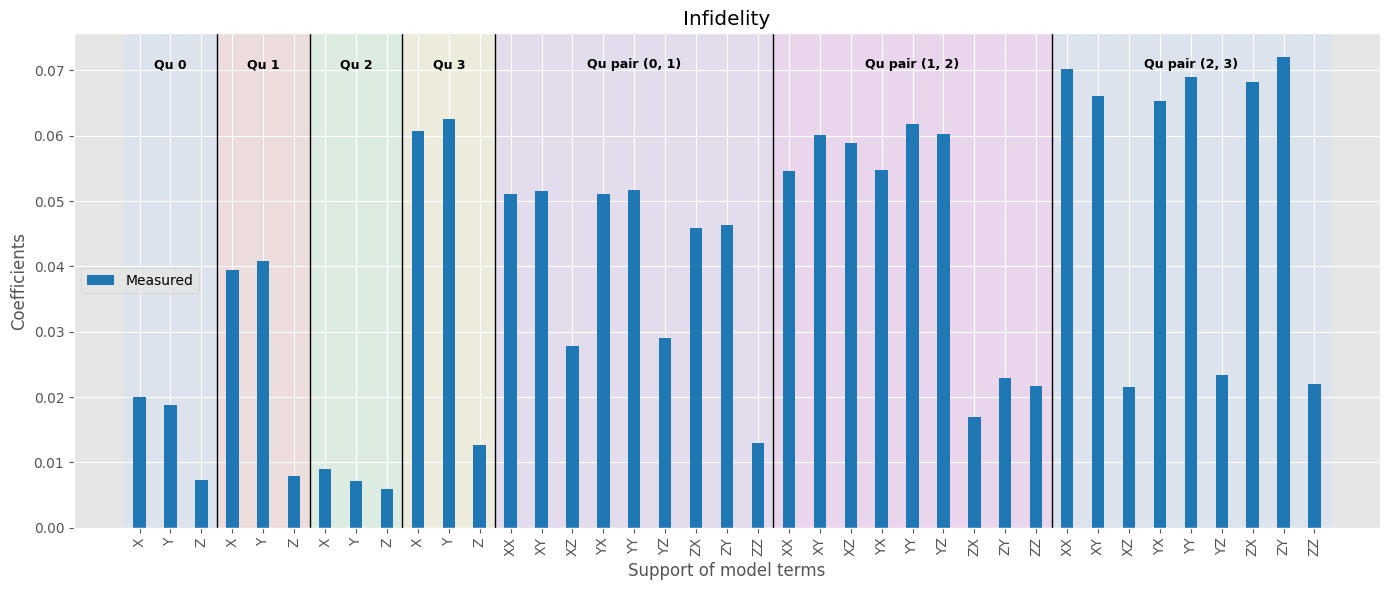

In [17]:
layer1 = experiment.analysis.get_layer_data(0)
layer1.plot_infidelitites(plot_style = 2)

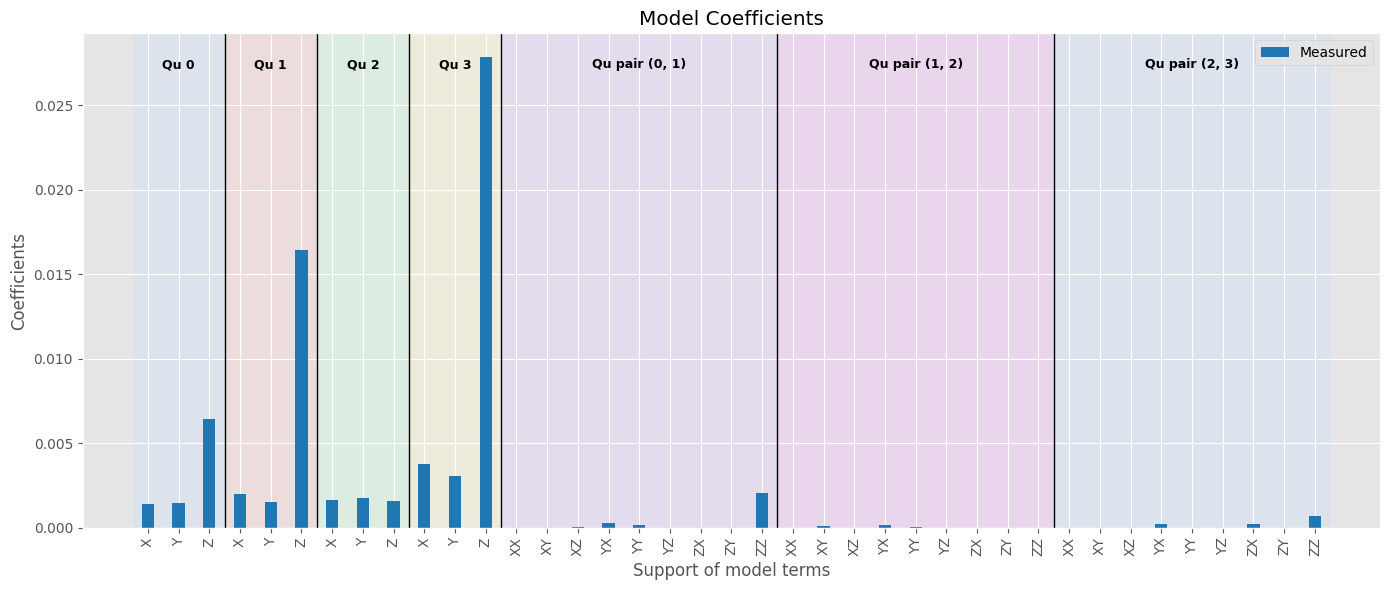

In [18]:
layer1.plot_coeffs(plot_style = 2)

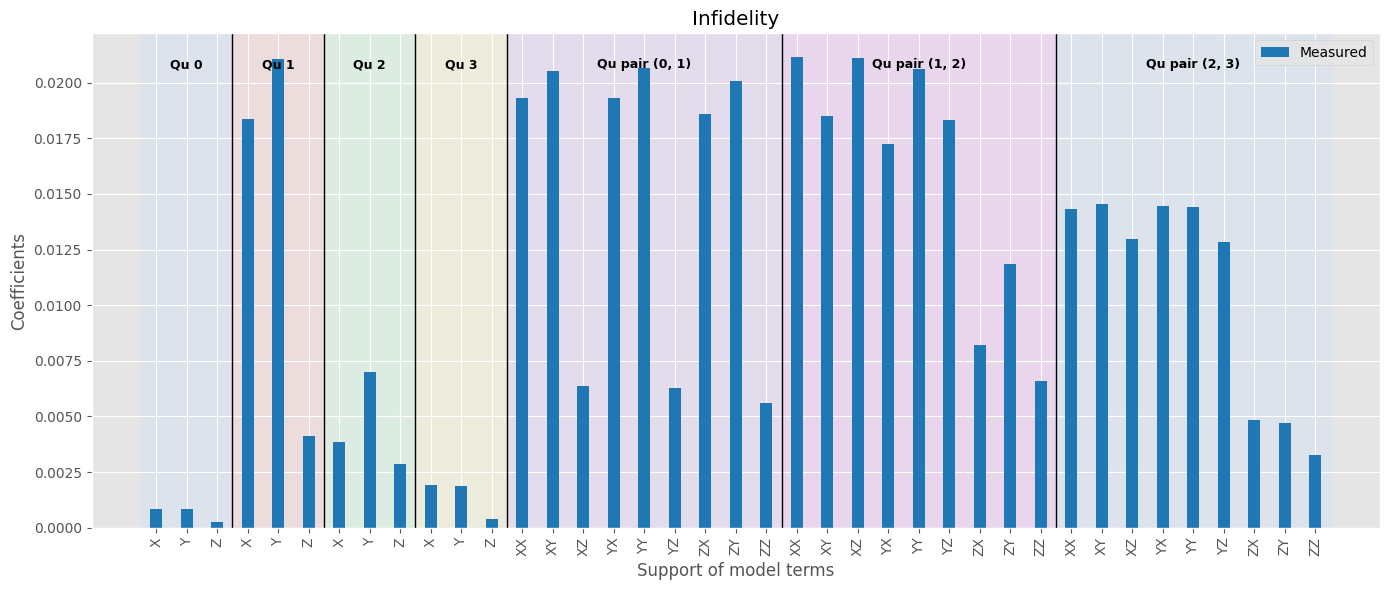

In [19]:
layer2 = experiment.analysis.get_layer_data(1)
layer2.plot_infidelitites(plot_style = 2)

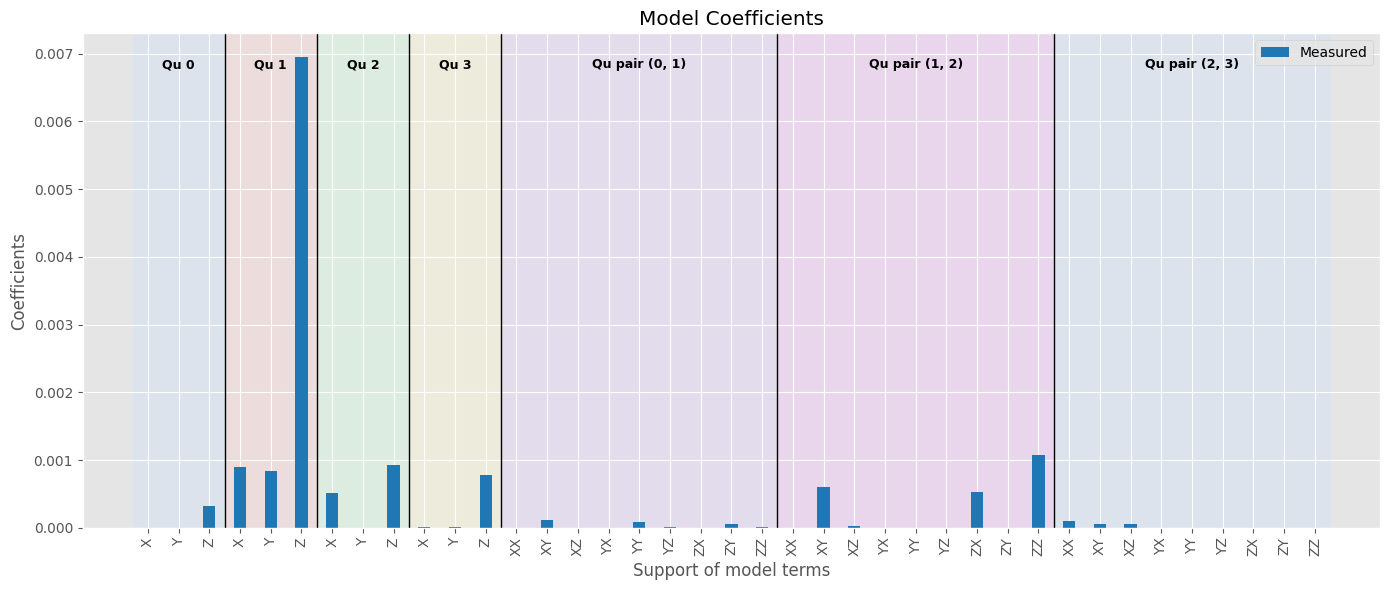

In [20]:
layer2.plot_coeffs(plot_style = 2)

In [21]:
# 2. PER-Experiment Setup
perexp = experiment.create_per_experiment([qc])

perexp.generate(
    expectations=pauli_list,
    samples=1000, 
    noise_strengths=[0, 1, 2]
)
perexp.run(executor)


=== PER ===
Circuits:       6000
Details:
  num_meas_bases_per : 2
  num_noise_strengths: 3
  samples            : 1000


Aus SV-Simulation:  0.9076948777961547


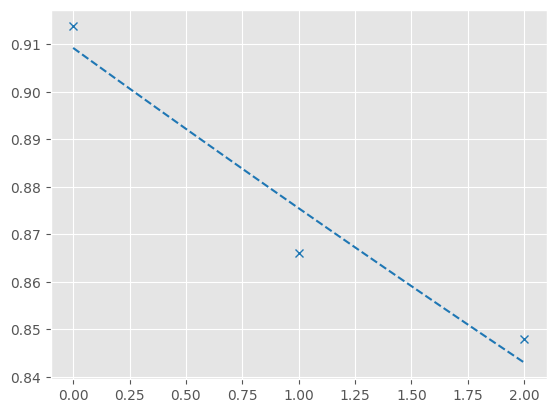

In [22]:
# 4. Analysieren
per_results = perexp.analyze()
result_1 = per_results[0].get_result(pauli_list[2]).plot()
print("Aus SV-Simulation: ",expectation_values[1])

In [23]:
# Compare absolute vs relative errors
for k in range(len(pauli_list)):
    exact = expectation_values[k]
    calc = per_results[0].get_result(pauli_list[k]).get_expectations()[0]
    abs_error = abs(exact - calc)
    rel_error = abs_error / abs(exact) if exact != 0 else float('inf')
    
    print(f"{pauli_list[k]}: Exact={exact:.4f}, Calc={calc:.4f}")
    print(f"  Absolute error: {abs_error:.6f}")
    print(f"  Relative error: {rel_error*100:.2f}%")
    print()

IIZZ: Exact=0.9077, Calc=0.9109
  Absolute error: 0.003248
  Relative error: 0.36%

IZZI: Exact=0.9077, Calc=0.8987
  Absolute error: 0.009034
  Relative error: 1.00%

ZZII: Exact=0.9077, Calc=0.9138
  Absolute error: 0.006064
  Relative error: 0.67%

IIIX: Exact=-0.2522, Calc=-0.2500
  Absolute error: 0.002176
  Relative error: 0.86%

IIIZ: Exact=-0.9527, Calc=-0.9717
  Absolute error: 0.018976
  Relative error: 1.99%

IIXI: Exact=-0.2653, Calc=-0.2708
  Absolute error: 0.005474
  Relative error: 2.06%

IIZI: Exact=-0.9527, Calc=-0.9503
  Absolute error: 0.002401
  Relative error: 0.25%

IXII: Exact=-0.2653, Calc=-0.2589
  Absolute error: 0.006361
  Relative error: 2.40%

IZII: Exact=-0.9527, Calc=-0.9625
  Absolute error: 0.009745
  Relative error: 1.02%

XIII: Exact=-0.2522, Calc=-0.2435
  Absolute error: 0.008647
  Relative error: 3.43%

ZIII: Exact=-0.9527, Calc=-0.9727
  Absolute error: 0.019929
  Relative error: 2.09%

